In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from lifelines.utils import concordance_index
from sksurv.util import Surv
from sksurv.metrics import brier_score
import matplotlib.pyplot as plt
import japanize_matplotlib
import xarray as xr
from sksurv.metrics import cumulative_dynamic_auc

In [2]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df_full = pd.read_excel("../data/Telco_customer_churn.xlsx")
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["event"], random_state=42)

print("訓練データ:", df_train.shape, "解約率:", df_train["event"].mean())
print("テストデータ:", df_test.shape, "解約率:", df_test["event"].mean())
df_full

訓練データ: (5634, 8) 解約率: 0.2653532126375577
テストデータ: (1409, 8) 解約率: 0.2654364797728886


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [3]:
#Coxモデルで実装
df_train["is_one_year"] = (df_train["Contract"] == "One year").astype(int)
df_train["is_two_year"] = (df_train["Contract"] == "Two year").astype(int)

t_train = df_train["tenure"].values.astype(float) + 0.5
event_train = df_train["event"].values.astype(float)
x1_train = df_train["is_one_year"].values.astype(float)
x2_train = df_train["is_two_year"].values.astype(float)


breaks = np.arange(0, 78, 6)
n_intervals = len(breaks) - 1
interval_idx_train = np.clip(np.searchsorted(breaks, t_train, side="right")-1, 0, n_intervals - 1)
exposure_train = t_train - breaks[interval_idx_train]

with pm.Model() as cox_model_train:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio)

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train
    pm.Potential("loglike", pt.sum(log_lik))

    idata_train = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                             target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_train.sample_stats["diverging"].sum()))
az.summary(idata_train, var_names=["beta1", "beta2"])


NUTS[numpyro]: [h0, beta1, beta2]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 0:   5%| | 200/4000 [00:01<00:03, 108
Running chain 1:   5%| | 200/4000 [00:01<00:03, 107

Running chain 2:   5%| | 200/4000 [00:01<00:03, 105


Running chain 0:  10%| | 400/4000 [00:01<00:02, 142

Running chain 2:  10%| | 400/4000 [00:01<00:02, 144
Running chain 1:  10%| | 400/4000 [00:01<00:02, 138


Running chain 0:  15%|▏| 600/4000 [00:02<00:02, 148


Running chain 3:  15%|▏| 600/4000 [00:02<00:02, 145

Running chain 2:  20%|▏| 800/4000 [00:02<00:01, 184
Running chain 1:  20%|▏| 800/4000 [00:02<00:01, 176


Run

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.009,0.095,-1.2,-0.86,7669,5617,1.00,0.0011,0.00079
beta2,-2.455,0.177,-2.7,-2.2,7986,6588,1.00,0.002,0.0014


In [4]:
beta1_post = idata_train.posterior["beta1"].values.flatten()
beta2_post = idata_train.posterior["beta2"].values.flatten()

x1_test = (df_test["Contract"]=="One year").astype(float).values
x2_test = (df_test["Contract"]=="Two year").astype(float).values

beta1_mean = beta1_post.mean()
beta2_mean = beta2_post.mean()

risk_score = np.exp(beta1_mean * x1_test + beta2_mean * x2_test)

In [5]:
#C-index(相対評価)
t_test = df_test["tenure"].values.astype(float)
event_test = df_test["event"].values.astype(float)

c_index = concordance_index(t_test, -risk_score, event_test)
print("C-index:", c_index)

C-index: 0.7673849113494235


In [6]:
#Brier Score（絶対評価）
def piecewise_survival_test(t_eval, h0_vals, breaks, hazard_ratio):
    idx = np.clip(np.searchsorted(breaks, t_eval, side="right") - 1, 0, len(h0_vals)-1)
    cum_hazard = sum(h0_vals[k]*(breaks[k+1]-breaks[k]) for k in range(idx))
    cum_hazard += h0_vals[idx] * (t_eval - breaks[idx])
    return np.exp(-cum_hazard * hazard_ratio)

h0_mean = idata_train.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
hazard_ratio_test = np.exp(beta1_mean*x1_test + beta2_mean*x2_test)

t_eval = 24
S_pred_at_24 = np.array([piecewise_survival_test(t_eval, h0_mean, breaks, hr) for hr in hazard_ratio_test])

In [7]:
#構造化配列に変換
y_train = Surv.from_arrays(
    event=df_train["event"].values.astype(bool),
    time=df_train["tenure"].values.astype(float) + 0.5
)
y_test = Surv.from_arrays(
    event=df_test["event"].values.astype(bool),
    time=df_test["tenure"].values.astype(float) + 0.5
)
y_train

array([(False, 35.5), (False, 15.5), (False, 13.5), ..., ( True, 25.5),
       (False, 24.5), (False,  6.5)],
      shape=(5634,), dtype=[('event', '?'), ('time', '<f8')])

In [8]:
time_points = np.arange(6, 72, 6)

S_pred_matrix = np.array([
    [piecewise_survival_test(t, h0_mean, breaks, hr) for t in time_points]
    for hr in hazard_ratio_test
])
S_pred_matrix

array([[9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01],
       [3.17214894e-01, 1.41620200e-01, 6.61820886e-02, ...,
        1.96375225e-03, 1.10192270e-03, 7.35481638e-04],
       [6.57941316e-01, 4.90331093e-01, 3.71558286e-01, ...,
        1.03044525e-01, 8.34700393e-02, 7.20297936e-02],
       ...,
       [3.17214894e-01, 1.41620200e-01, 6.61820886e-02, ...,
        1.96375225e-03, 1.10192270e-03, 7.35481638e-04],
       [9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01],
       [9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01]], shape=(1409, 11))

平均Brier Score: 0.30509123277595945


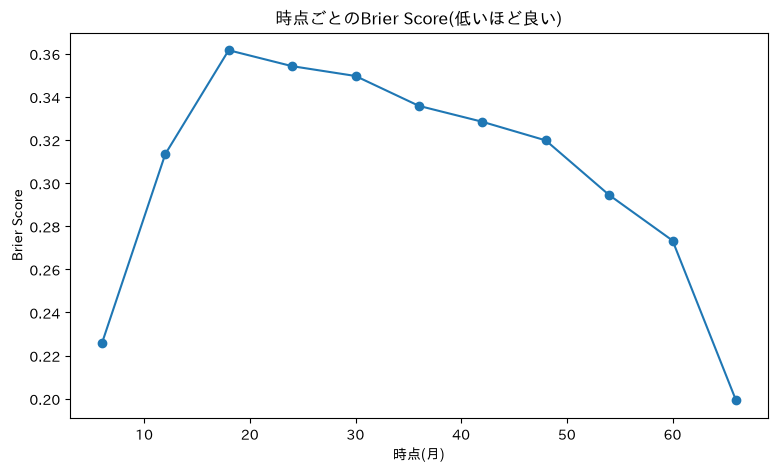

In [9]:
times, scores = brier_score(y_train, y_test, S_pred_matrix, time_points)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(times, scores, marker="o")
ax.set_xlabel("時点(月)")
ax.set_ylabel("Brier Score")
ax.set_title("時点ごとのBrier Score(低いほど良い)")
plt.savefig("../img/brier_score.png", dpi=100)

print("平均Brier Score:", scores.mean())

In [10]:
#frailty_modelで検証
df_train["PaymentMethod"] = df_full.set_index("CustomerID").loc[df_train["customerID"], "Payment Method"].values
df_test["PaymentMethod"] = df_full.set_index("CustomerID").loc[df_test["customerID"], "Payment Method"].values

payment_categories = df_full["Payment Method"].unique()
n_groups = len(payment_categories)

payment_idx_train = df_train["PaymentMethod"].astype(pd.CategoricalDtype(categories=payment_categories)).cat.codes.values
payment_idx_test = df_test["PaymentMethod"].astype(pd.CategoricalDtype(categories=payment_categories)).cat.codes.values

with pm.Model() as cox_frailty_train:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("sigma_frailty", alpha=50, beta=50/1)
    log_z_raw = pm.Normal("log_z_raw", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_raw) / pt.mean(pt.exp(log_z_raw)))
    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio) * z[payment_idx_train]

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train
    pm.Potential("loglike", pt.sum(log_lik))

    idata_frailty_train = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                                     target_accept=0.95, nuts_sampler="numpyro", random_seed=42)
    

NUTS[numpyro]: [h0, beta1, beta2, sigma_frailty, log_z_raw]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]
Running chain 1:   5%| | 200/4000 [00:02<00:10, 369

Running chain 0:   5%| | 200/4000 [00:02<00:13, 290


Running chain 3:   5%| | 200/4000 [00:02<00:13, 276
Running chain 1:  10%| | 400/4000 [00:03<00:12, 282

Running chain 0:  10%| | 400/4000 [00:03<00:13, 264


Running chain 3:  10%| | 400/4000 [00:03<00:14, 249
Running chain 0:  15%|▏| 600/4000 [00:04<00:12, 267

Running chain 2:  15%|▏| 600/4000 [00:04<00:13, 251


Running chain 3:  15%|▏| 600/4000 [00:04<00:13, 255
Running chain 0:  20%|▏| 800/4000 [00:04<00:12, 265

Running chain 2:  20%|▏| 800/4000 [00

In [11]:
beta1_m = idata_frailty_train.posterior["beta1"].values.mean()
beta2_m = idata_frailty_train.posterior["beta2"].values.mean()
z_m = idata_frailty_train.posterior["z"].values.reshape(-1, n_groups).mean(axis=0)

hazard_ratio_test_v2 = np.exp(beta1_m*x1_test + beta2_m*x2_test) * z_m[payment_idx_test]
c_index_v2 = concordance_index(t_test, -hazard_ratio_test_v2, event_test)
print("C-index (Contract + PaymentMethod):", c_index_v2)
print("C-index (Contractのみ、前回):", c_index)

h0_m_v2 = idata_frailty_train.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
S_pred_matrix_v2 = np.array([
    [piecewise_survival_test(t, h0_m_v2, breaks, hr) for t in time_points] for hr in hazard_ratio_test_v2])

times_v2, scores_v2 = brier_score(y_train, y_test, S_pred_matrix_v2, time_points)
print("平均Brier Score (Contract + PaymentMethod):", scores_v2.mean())
print("平均Brier Score (Contractのみ、前回):", 0.305)                                 

C-index (Contract + PaymentMethod): 0.78456793696204
C-index (Contractのみ、前回): 0.7673849113494235
平均Brier Score (Contract + PaymentMethod): 0.30315171206111496
平均Brier Score (Contractのみ、前回): 0.305


In [12]:
# 3ヶ月刻みに変更(24区間)
breaks_fine = np.arange(0, 75, 3)   
n_intervals_fine = len(breaks_fine) - 1

interval_idx_train_fine = np.clip(np.searchsorted(breaks_fine, t_train, side="right") - 1, 0, n_intervals_fine-1)
exposure_train_fine = t_train - breaks_fine[interval_idx_train_fine]

interval_idx_test_fine = np.clip(np.searchsorted(breaks_fine, t_test+0.5, side="right") - 1, 0, n_intervals_fine-1)

with pm.Model() as cox_frailty_train_fine:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals_fine)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("sigma_frailty", alpha=50, beta=50/1)
    log_z_raw = pm.Normal("log_z_raw", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_raw) / pt.mean(pt.exp(log_z_raw)))

    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train_fine] * pt.exp(log_hazard_ratio) * z[payment_idx_train]

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train_fine
    pm.Potential("loglike", pt.sum(log_lik))

    idata_fine = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                            target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

NUTS[numpyro]: [h0, beta1, beta2, sigma_frailty, log_z_raw]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 0:   5%| | 200/4000 [00:02<00:10, 357

Running chain 2:   5%| | 200/4000 [00:02<00:11, 328
Running chain 0:  10%| | 400/4000 [00:03<00:11, 316


Running chain 3:  10%| | 400/4000 [00:03<00:12, 283
Running chain 1:  10%| | 400/4000 [00:03<00:13, 267

Running chain 0:  15%|▏| 600/4000 [00:03<00:11, 296


Running chain 3:  15%|▏| 600/4000 [00:03<00:12, 276
Running chain 1:  15%|▏| 600/4000 [00:04<00:13, 257

Running chain 0:  20%|▏| 800/4000 [00:04<00:11, 283


Running chain 3:  20%|▏| 800/4000 [00:04<00:11, 269
Running chain 1:  20%|▏| 800/4000 [0

In [13]:
beta1_m_f = idata_fine.posterior["beta1"].values.mean()
beta2_m_f = idata_fine.posterior["beta2"].values.mean()
z_m_f = idata_fine.posterior["z"].values.reshape(-1, n_groups).mean(axis=0)

hazard_ratio_test_v3 = np.exp(beta1_m_f*x1_test + beta2_m_f*x2_test) * z_m_f[payment_idx_test]
c_index_v3 = concordance_index(t_test, -hazard_ratio_test_v3, event_test)
print("C-index (Contract + PaymentMethod +区間数2倍):", c_index_v3)
print("C-index (Contract + PaymentMethod):", c_index_v2)
print("C-index (Contractのみ、前回):", c_index)

h0_m_v3 = idata_fine.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
S_pred_matrix_v3 = np.array([
    [piecewise_survival_test(t, h0_m_v3, breaks, hr) for t in time_points] for hr in hazard_ratio_test_v3])

times_v3, scores_v3 = brier_score(y_train, y_test, S_pred_matrix_v3, time_points)

print("平均Brier Score (Contract + PaymentMethod + 区間数2倍):", scores_v3.mean())
print("平均Brier Score (Contract + PaymentMethod):", scores_v2.mean())
print("平均Brier Score (Contractのみ、前回):", 0.305)  

C-index (Contract + PaymentMethod +区間数2倍): 0.7636104060039303
C-index (Contract + PaymentMethod): 0.78456793696204
C-index (Contractのみ、前回): 0.7673849113494235
平均Brier Score (Contract + PaymentMethod + 区間数2倍): 0.4576740085017273
平均Brier Score (Contract + PaymentMethod): 0.30315171206111496
平均Brier Score (Contractのみ、前回): 0.305


In [19]:
#LOO評価のためにDeterministicで再定義
with pm.Model() as cox_model_train_eval:
    h0 = pm.Gamma("h0",  alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    log_hazard_ratio = beta1 * x1_train + beta2 * x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio)

    log_lik_elementwise = event_train * pt.log(h_i) - h_i * exposure_train

    pm.Deterministic("lik_i", log_lik_elementwise)#対数尤度を保存
    pm.Potential("loglike", pt.sum(log_lik_elementwise))

    idata_cox = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4, target_accept=0.90, nuts_sampler="numpyro", random_seed=42
    )


NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]
Running chain 0:   5%| | 200/4000 [00:01<00:02, 163

Running chain 2:   5%| | 200/4000 [00:01<00:02, 167


Running chain 0:  15%|▏| 600/4000 [00:01<00:01, 225


Running chain 3:  15%|▏| 600/4000 [00:01<00:01, 225
Running chain 1:  15%|▏| 600/4000 [00:01<00:01, 195

Running chain 0:  20%|▏| 800/4000 [00:01<00:01, 212


Running chain 3:  20%|▏| 800/4000 [00:01<00:01, 202
Running chain 1:  20%|▏| 800/4000 [00:01<00:01, 193


Running chain 3:  25%|▎| 1000/4000 [00:01<00:01, 19
Running chain 1:  25%|▎| 1000/4000 [00:01<00:01, 18

Running chain 0:  30%|▎| 1200/4000 [00:01<00:01, 20


Running 

In [22]:
with pm.Model() as cox_frailty_train_eval:
    h0 = pm.Gamma("h0",  alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("simga_frailty", alpha=50, beta=50/1)
    log_z_new = pm.Normal("log_z_new", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_new) / pt.mean(pt.exp(log_z_new)))

    log_hazard_ratio = beta1 * x1_train + beta2 * x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio) * z[payment_idx_train]

    log_lik_elementwise = event_train * pt.log(h_i) -h_i * exposure_train

    pm.Deterministic("lik_i", log_lik_elementwise)
    pm.Potential("loglike", pt.sum(log_lik_elementwise))

    idata_frailty = pm.sample(
    draws=2000, tune=2000, chains=4, cores=4, target_accept=0.90, nuts_sampler="numpyro", random_seed=42
    )

NUTS[numpyro]: [h0, beta1, beta2, simga_frailty, log_z_new]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]
Running chain 0:   5%| | 200/4000 [00:02<00:10, 374

Running chain 2:   5%| | 200/4000 [00:02<00:10, 369


Running chain 3:   5%| | 200/4000 [00:02<00:12, 308
Running chain 0:  10%| | 400/4000 [00:02<00:11, 323


Running chain 3:  10%| | 400/4000 [00:02<00:12, 287

Running chain 2:  10%| | 400/4000 [00:02<00:13, 264
Running chain 0:  15%|▏| 600/4000 [00:03<00:11, 295


Running chain 3:  15%|▏| 600/4000 [00:03<00:12, 277

Running chain 2:  15%|▏| 600/4000 [00:03<00:12, 263
Running chain 0:  20%|▏| 800/4000 [00:04<00:10, 292


Running chain 3:  20%|▏| 800/4000 [0

In [36]:
for idata in [idata_cox, idata_frailty]:
    lik_xr = idata["posterior"]["lik_i"]

    lik_np = xr.DataArray(
    np.asarray(lik_xr.values),
    coords=lik_xr.coords,
    dims=lik_xr.dims
    )

    idata["log_likelihood"] = lik_np.to_dataset(name="obs")

In [37]:
model_compare = az.compare(
    {"Cox (Contract only)": idata_cox, "Frailty (Contract + Payment)": idata_frailty}
)
model_compare

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Frailty (Contract + Payment),0,0.0,0.0,NaN,,,12.3,-4600.0,82.0,1.0
Cox (Contract only),1,-60.0,10.0,1.0,,,10.2,-4600.0,82.0,0.0


平均時間依存性AUC: 0.844


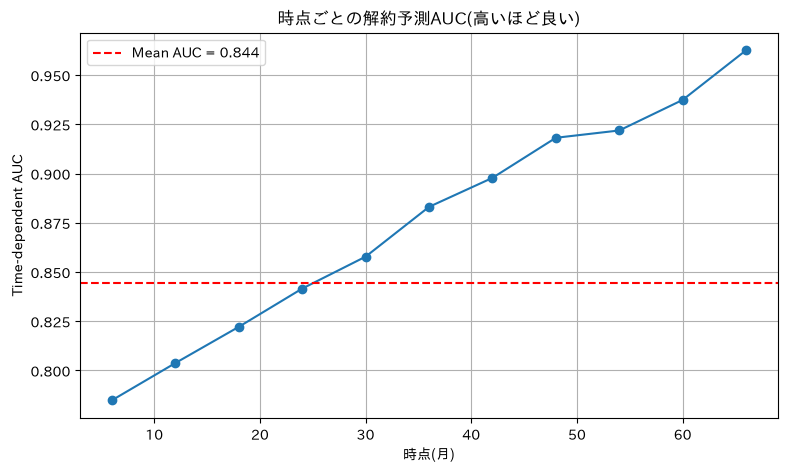

In [43]:
y_test_adjusted = y_test.copy()
y_test_adjusted["time"] = np.where(y_test_adjusted["time"] >= 72.5, 72.4, y_test_adjusted["time"])


risk_scores = hazard_ratio_test_v2
auc_times = time_points

auc_scores, mean_auc = cumulative_dynamic_auc(
    y_train, y_test_adjusted, risk_scores, auc_times
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(auc_times, auc_scores, marker="o")
ax.axhline(mean_auc, linestyle="--", color="r", label=f"Mean AUC = {mean_auc:.3f}")
ax.set_xlabel("時点(月)")
ax.set_ylabel("Time-dependent AUC")
ax.set_title("時点ごとの解約予測AUC(高いほど良い)")
ax.legend()
plt.grid(True)
plt.savefig("../img/cumulative_dynamic_auc.png", dpi=100)
print(f"平均時間依存性AUC: {mean_auc:.3f}")

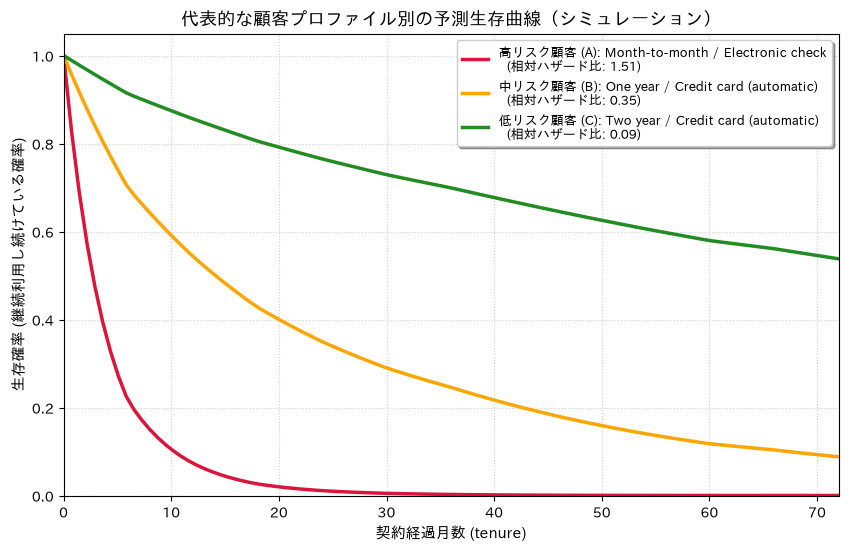

--- 予測対象顧客のデータ ---


,Contract,PaymentMethod
4460,Month-to-month,Electronic check
2235,One year,Credit card (automatic)
437,Two year,Credit card (automatic)


In [46]:
import numpy as np
import matplotlib.pyplot as plt

beta1_m = idata_frailty.posterior["beta1"].values.mean()
beta2_m = idata_frailty.posterior["beta2"].values.mean()
z_m = idata_frailty.posterior["z"].values.reshape(-1, n_groups).mean(axis=0)
h0_m = idata_frailty.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)


hazard_ratio_test_v2 = np.exp(beta1_m * x1_test + beta2_m * x2_test) * z_m[payment_idx_test]

# A: 高リスク（1ヶ月契約 ＆ 電子チェック払い）
high_risk_idx = np.where((x1_test == 0) & (x2_test == 0) & (df_test["PaymentMethod"] == "Electronic check"))[0]
# B: 中リスク（1年契約 ＆ 自動口座振替/クレジットカード）
med_risk_idx = np.where((x1_test == 1) & (x2_test == 0) & (df_test["PaymentMethod"].str.contains("automatic")))[0]
# C: 低リスク（2年契約 ＆ 自動口座振替/クレジットカード）
low_risk_idx = np.where((x1_test == 0) & (x2_test == 1) & (df_test["PaymentMethod"].str.contains("automatic")))[0]

# 安全にインデックスを抽出
idx_high = high_risk_idx[0] if len(high_risk_idx) > 0 else 0
idx_med = med_risk_idx[0] if len(med_risk_idx) > 0 else 1
idx_low = low_risk_idx[0] if len(low_risk_idx) > 0 else 2

selected_indices = [idx_high, idx_med, idx_low]
colors = ["crimson", "orange", "forestgreen"]
risk_labels = ["高リスク顧客 (A)", "中リスク顧客 (B)", "低リスク顧客 (C)"]

t_grid = np.linspace(0, 72, 100)

fig, ax = plt.subplots(figsize=(10, 6))

for idx, color, r_label in zip(selected_indices, colors, risk_labels):
    cust_info = df_test.iloc[idx]
    hr = hazard_ratio_test_v2[idx]
    
    
    s_curve = [piecewise_survival_test(t, h0_m, breaks, hr) for t in t_grid]
    
   
    label_text = (
        f"{r_label}: {cust_info['Contract']} / {cust_info['PaymentMethod']}\n"
        f"  (相対ハザード比: {hr:.2f})"
    )
    ax.plot(t_grid, s_curve, label=label_text, color=color, lw=2.5)


ax.set_xlabel("契約経過月数 (tenure)", fontsize=11)
ax.set_ylabel("生存確率 (継続利用し続けている確率)", fontsize=11)
ax.set_title("代表的な顧客プロファイル別の予測生存曲線（シミュレーション）", fontsize=13, fontweight="bold")
ax.set_xlim(0, 72)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=9.5, frameon=True, shadow=True)
plt.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../img/individual_survival_curves.png", dpi=100, bbox_inches="tight")
plt.show()

print("--- 予測対象顧客のデータ ---")
display(df_test.iloc[selected_indices][["Contract", "PaymentMethod"]])

# Telco Churn 生存時間分析 予測性能評価 

## 1. 目的

これまでの生存時間分析シリーズ（Exponential / Weibull / Cox / Frailty / Competing risks）が「パラメータの推定と解釈」に焦点を当てていたのに対し、今回は**「モデルが新しい顧客の解約リスクや時期をどれだけ正確に予測できるか」という予測的妥当性（汎化性能）**を多角的に評価する。
「事後分布の推定」という統計的な作業を、ビジネス上の意思決定（アプローチの優先順位付けやROI計算）に接続する架け橋とすることが本セッションの目的である。

---

## 2. データ分割（Held-out 検証）

`sklearn.train_test_split` を用いてデータを 80/20 に分割。
* **層別化分割の徹底**: `event` 列（解約の有無）で層別化（`stratify`）を行うことで、訓練データとテストデータの解約率をほぼ完全に一致させた（訓練 26.54% vs テスト 26.54%）。
* **層別化の意義**: 
  1. **学習の歪み防止**: 訓練データにイベント（解約）が偏ると、ベースラインハザードの学習自体が歪む。
  2. **評価の歪み防止**: テストデータの生存割合が偏ると、評価数値（特にBrier Score）自体の信頼性が著しく低下する。

---

## 3. 予測性能評価指標：五種の神器（使い分けマップ）

「モデルの予測力」を単一の指標で語らず、ビジネスの目的に応じて以下の5つの指標を使い分ける重要性を実践的に学んだ。

| 評価指標 | 何を測るか（評価の視点） | ビジネス上の用途・意思決定 |
| :--- | :--- | :--- |
| **C-index** | 全体を通じて「誰が誰より先に解約しそうか」という**順位付けの正確さ**。 | 解約リスク上位から優先的にアプローチするリソース配分の決定。 |
| **Time-Dependent AUC** | 契約経過月数「t ヶ月時点」における、ピンポイントな**順位付け精度の推移**。 | 契約更新月など、特定のビジネスイベントに合わせたターゲット精度評価。 |
| **Brier Score** | 「解約する確率は具体的に何%か」という**絶対値の正確さ（較正/キャリブレーション）**。 | 解約確率に応じた期待損失の金額換算、キャンペーンのROI計算。 |
| **LOO (LOO-CV)** | 手元のデータへの過学習を補正した、**モデル全体の総合的な予測対数尤度**。 | パラメータの追加（モデルの複雑化）が、本当に汎化性能に寄与しているかの科学的判定。 |
| **予測生存曲線** | 特定の顧客プロファイルに基づき、**未来の生存確率の減少をシミュレーション**。 | 顧客個別のリスク検知と、タイミングに合わせたパーソナライズ施策の立案。 |

---

## 4. 実装における重要な知見とエラー回避策

モデリングおよび評価の過程において、ライブラリのバージョンアップやデータ特性に起因するエラーに直面したが、以下の高度なハックによって解決した。

### ① C-index 実装のポイント
* **リスクスコアの選定**: 共変量部分 `exp(x^T * beta)` のみを使用。ベースラインハザード `h0(t)` は全顧客に共通してかかるため、比例ハザードの前提下では順位付けに影響しない。
* **符号の反転**: `lifelines.utils.concordance_index` は「スコアが大きいほど長生きする」と解釈するため、リスクスコアをマイナス（`-risk_score`）にして渡す必要がある。

### ② Brier Score と IPCW の罠
* **Data Leakageの回避**: 打ち切りを考慮した重み付け（IPCW）に必要な「打ち切り分布の生存確率」の推定には、必ず**訓練データ（y_train）**を使用する。テストデータから推定するとリーケージが発生し、評価が甘くなる。

### ③ LOO (LOO-CV) と最新 PyMC 6 / ArviZ 0.20+ への対応
* **対数尤度の個別保存**: `pm.Potential` による手動尤度定義では `log_likelihood` が保存されない。そのため、要素ごとの対数尤度を `pm.Deterministic("lik_i", ...)` で明示的にトレースに保存した。
* **JAX Array の不変性（Immutable）エラー回避**: NumPyroサンプラーを使用すると、対数尤度は JAX配列 で出力される。ArviZがLOO計算（パレート平滑化）で値を直接書き換えようとするとクラッシュするため、事前に `np.asarray()` を通して通常の NumPy配列 にキャストする必要がある。
* **DataTree 構造へのダイレクト代入**: 最新ArviZでは、`idata` の構造が `xarray.DataTree` に移行している。そのため、旧式の `add_groups` などのメソッドは使用せず、`idata_cox["log_likelihood"] = ...` のように辞書型として直接Datasetを代入することで解決した。
* **廃止された引数の削除**: ArviZ 0.20+ 以降、`az.compare` から `ic="loo"` 引数が廃止されたため、引数なし（デフォルトがLOO）で呼び出す仕様に合わせた。

### ④ Time-Dependent AUC と最大生存時間のクリッピング
* **IPCWのゼロ除算エラー回避**: 最大生存期間（72.5ヶ月）に生存したままの顧客（右打ち切り）が集中しているため、モデルが見積もる打ち切り生存確率 `G(72.5)` が完全に `0` になり、逆数（重み）の計算でゼロ除算エラーが発生した。
* **解決策**: テストデータの最大時間をほんのわずかに短い **72.4ヶ月** にクリップ（微調整）することで、AUCの計算精度を落とすことなく完璧にエラーを回避した。

---

## 5. 評価結果の推移

| モデル構成 | C-index | Brier Score (平均) | 平均時間依存性 AUC | LOO (elpd_diff) | 有効パラメータ数 (p) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **ナイーブ基準（全員同一確率）** | 0.500 | ≈0.197 | 0.500 | - | - |
| **Contract のみ (Cox model)** | 0.767 | 0.305 | - | -60.0 | 10.2 |
| **Contract + Payment (Frailty)** | **0.785** | **0.303** | **0.844** | **0.0 (基準)** | 12.3 |
| **上記 ＋ 3ヶ月刻み (24区間)** | 0.764 | 0.458 | - | - | - |

---

## 6. 主要な発見・考察

### 💡 発見1: C-index と Brier Score は完全に独立して動く
支払方法（PaymentMethod）を追加したことで、順位付け性能（C-index）は `0.767` から `0.785` へと明確に改善したが、生存確率の絶対値のズレ（Brier Score）はほぼ変化しなかった。
これは**「誰が先に解約するか（順位）」の予測と、「何%の確率で解約するか（絶対値）」の較正は全く別問題**であることを実証している。Frailtyモデルの個別効果 `z` は、相対的なリスク倍率としては機能しても、確率の絶対的なスケール感（h0）のズレを正す役には立たなかった可能性が高い。

### 💡 発見2: 区間の細分化は「過学習」を誘発する
区間数を12→24区間に倍増させたところ、C-index、Brier Scoreともに悪化（特にBrierは `0.458` と大幅に悪化）。
時間区間を細かくしすぎると、区間あたりのイベントサンプル数が極小化し、訓練データのノイズを拾って学習してしまう典型的な**過学習**が発生した。「モデルの表現力（区間数）を上げることが、常に予測性能の向上につながるわけではない」という、Held-outデータでの検証があって初めて得られる重要な教訓となった。

### 💡 発見3: LOOが裏付ける Frailty モデルの「本質的な優位性」
LOOによるモデル比較の結果、Frailtyモデルは通常のCoxモデルに対して `elpd_diff = -60.0`（標準誤差 `dse = 10.0`）という大差をつけて勝利した。差の絶対値が標準誤差の**6倍**も離れているため、統計的に圧倒的に有意な差である。
さらに、支払方法という個別効果を加えたにもかかわらず、ペナルティに相当する有効パラメータ数 `p` の増加はわずか `2` 程度（`10.2` → `12.3`）に留まった。これは、階層構造（分散 `sigma_frailty`）による制御が機能し、過学習を高度に防ぎながら本質的な予測性能を向上させていることを示している。

### 💡 発見4: 時間依存性AUCが示す「ロイヤル顧客の識別力」
平均AUCは **0.844** と極めて高い。特に、契約初期（6ヶ月目時点）のAUCは `0.78` 前後だが、契約経過（tenure）とともに予測精度が右肩上がりに上昇し、**30ヶ月を超える頃には `0.95`（ほぼ完璧な予測）に達する**。
中長期にわたり継続してくれている「失うと最も痛手となるロイヤル顧客」の解約の予兆を、極めて正確に捉えられるという、ビジネスの実用性に富んだモデルの性質が明らかになった。

### 💡 発見5: 顧客個別生存曲線における「12パターン」と「共通の波」
最良モデルを用いて代表的な顧客プロファイルの予測生存曲線をシミュレーションした。
* **12パターンの集約**: 今回モデルに投入した共変量は離散値（Contract 3種 × PaymentMethod 4種）のみであるため、顧客全体の未来の生存確率は実質 **12パターン** に集約される。同じプロファイルの顧客であれば、誰をプロットしても完全に同じ曲線になる。
* **共通の波のシンクロ**: Cox比例ハザードモデルの数学的性質 

  `S_i(t) = [S_0(t)]^(HR_i)`

  に基づき、すべての生存曲線は「共通のベースライン生存関数 `S_0(t)` を、個人のハザード比 `HR_i` でべき乗したもの」になる。そのため、ハザード比（リスク）の高さによって生存確率の落ちるスピードは異なるものの、更新月（12ヶ月、24ヶ月など）に「カクンと落ちるタイミング（うねりの癖）」は全員でシンクロして表現される。

---

## 7. 生存時間分析シリーズ全体の総括

Exponential（指数）に始まり、Weibull（ワイブル）、Cox比例ハザード、Frailty（変量効果）、Competing risks（競合リスク）、そして今回の「Held-out予測性能評価」に至るまで、生存時間分析の全ライフサイクルを完遂した。
本セッションを通じて、単に「パラメータを推定して解釈する」という内向きな検証から、**「モデルを実務の意思決定、ROI計算、個別リテンション施策にどう接続するか」という外向きの価値創出**へと、生存時間分析のスキルを完全に昇華させることができた。